In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
os.makedirs('models', exist_ok=True)

dataset_path = 'data/customers.csv'
try:
    df = pd.read_csv(dataset_path)
except FileNotFoundError:
    print(f"No file in path {dataset_path}.")
    exit()


In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.rename(columns={
    'Annual Income (k$)':'Annual Income',
    'Spending Score (1-100)': 'Spending Score'
}, inplace=True)

In [6]:
# Basic statistics of data
df.describe()

,CustomerID,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
# check for missing values
df.isnull().sum()

CustomerID        0
Gender            0
Age               0
Annual Income     0
Spending Score    0
dtype: int64

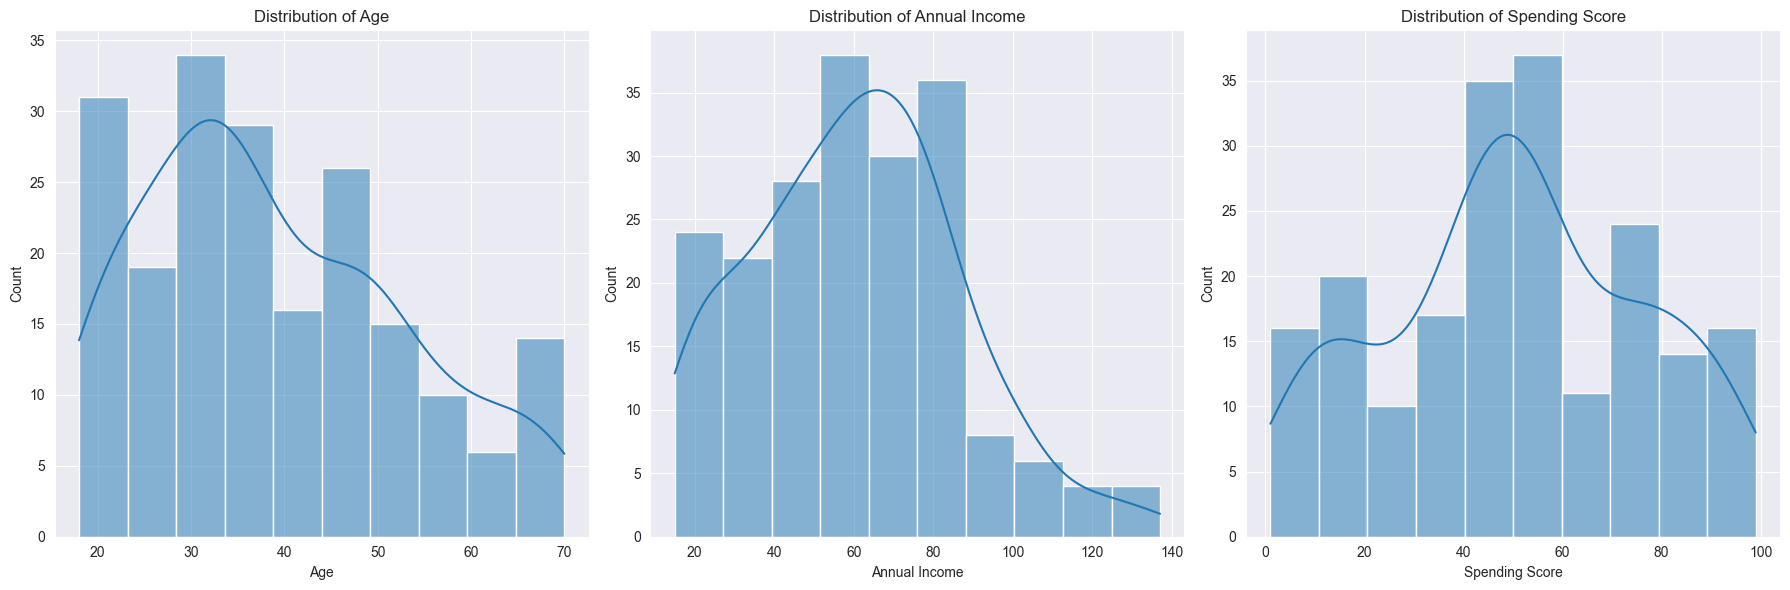

In [9]:
# Plot distrubtions

plt.figure(figsize=(18, 6))
for i, feature in enumerate(['Age', 'Annual Income', 'Spending Score'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[feature], kde=True, bins=10)
    plt.title(f"Distribution of {feature}")

plt.tight_layout()
plt.savefig('models/graphs_distributions.png')
plt.show()

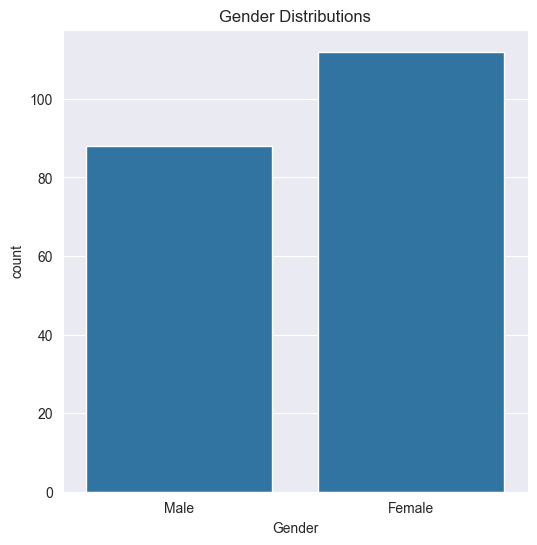

In [10]:
# Gender plots

plt.figure(figsize=(6, 6))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distributions")
plt.savefig('models/gender_distributions.png')
plt.show()

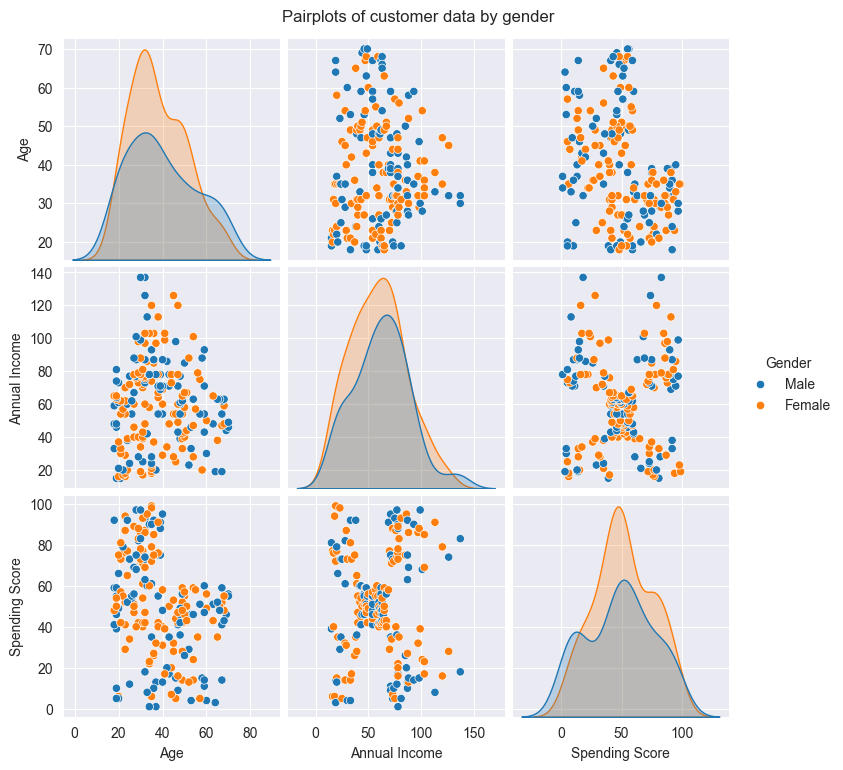

In [11]:
# pairplots with gender as a hue paramters

sns.pairplot(df, vars=['Age', 'Annual Income', 'Spending Score'], hue='Gender')
plt.suptitle('Pairplots of customer data by gender', y=1.02)
plt.savefig('models/pairplot.png')
plt.show()

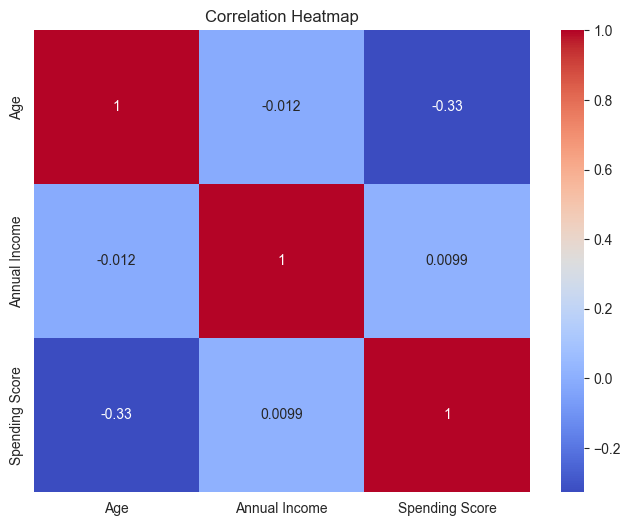

In [13]:
# Correalation between all the parameters

plt.figure(figsize=(8, 6))
sns.heatmap(df[['Age', 'Annual Income', 'Spending Score']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig('models/correlation_heatmap.png')
plt.show()